In [6]:
import numpy as np
import scipy.io
# Convert networkx graphs to PyTorch Geometric Data objects
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, GCNConv, GATConv, SAGEConv, global_add_pool
import torch.nn as nn
import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, ChebConv, SAGEConv, global_mean_pool
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import networkx as nx
# import bct

In [7]:
import numpy as np
import mne
import h5py
from scipy.stats import spearmanr

def extract_filtered_eeg(i):
    """ Load, preprocess EEG data, and extract connectivity features. """

    raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A0{i}T.gdf',
                              eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
    raw.set_eeg_reference()

    channel_rename_dict = {
        'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
        'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4',
        'EEG-8': 'C6', 'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
        'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'
    }
    raw.rename_channels(channel_rename_dict)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))

    events, event_id = mne.events_from_annotations(raw)
    epoch = mne.Epochs(raw, events, event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, preload=True)

    labels = epoch.events[:, -1] - 7
    labels = np.array(labels)  # Ensure labels are NumPy array
    epoch.apply_baseline((-1.5, 0.0))
    file_path = f'/Users/siddharth/Documents/Brainconnectivity/filtered_Artifacts_removed/filt_PreProc_EEG_ICA_filt_sub{i}.mat'
    
    def recursive_get_data(group, file):
        """ Recursively extract HDF5 data. """
        data = {}
        for key in group:
            item = group[key]
            if isinstance(item, h5py.Group):
                data[key] = recursive_get_data(item, file)
            elif isinstance(item, h5py.Dataset):
                data[key] = item[:]
            elif isinstance(item, h5py.Reference):
                ref_obj = file[item]
                if isinstance(ref_obj, h5py.Dataset):
                    data[key] = ref_obj[:]
                elif isinstance(ref_obj, h5py.Group):
                    data[key] = recursive_get_data(ref_obj, file)
        return data

    with h5py.File(file_path, 'r') as f:
        all_data = recursive_get_data(f, f)

    eeg_data = []
    for key in all_data.get('#refs#', {}):
        ref_group = all_data['#refs#'][key]
        if ref_group.shape[0] == 751:
            eeg_data.append(ref_group)

    eeg_data = np.stack(eeg_data, axis=0).reshape(144, 22, 751)  # Adjust shape if needed

    return eeg_data, labels, epoch['769'].average()

In [8]:
import numpy as np

# Initialize empty lists to store EEG data and labels
eeg_data = []
labels = []

# Iterate over subjects (assuming subject indices from 2 to 9)
for i in range(2, 10):
    i = 8  # Setting subject index to 8 as per your current code
    data, label, info = extract_filtered_eeg(i)  # Assuming `extract_filtered_eeg` function returns data, label, and info
    
    eeg_data.append(data)  # Append EEG data for the current subject
    labels.append(label)    # Append labels for the current subject

# Convert EEG data and labels to NumPy arrays for further processing
eeg_data = np.array(eeg_data)  # Shape: (num_subjects, num_trials, num_channels, num_datapoints)
labels = np.array(labels)      # Shape: (num_subjects, num_trials)


eeg_data = eeg_data.reshape(-1, 22, eeg_data.shape[-1])  # Shape: (num_trials, num_channels, feature_dim)
labels = labels.reshape(-1)  # Shape: (num_trials, num_channels, feature_dim)

# Print the shape of the final EEG data and labels arrays
print("EEG Data Shape:", eeg_data.shape)  # Expected shape: (num_subjects, num_trials, num_channels, num_datapoints)
print("Labels Shape:", labels.shape)      # Expected shape: (num_subjects, num_trials)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 675269  =      0.000 ...  2701.076 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
EEG Data Shape: (1152, 22, 751)
Labels Shape: (1152,)


In [9]:
labels = labels.reshape(-1)  # Shape: (num_trials, num_channels, feature_dim)

In [10]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [2]:
import numpy as np
import scipy.io

# Initialize an empty list to store features
features = []

# Iterate over subjects
for i in range(2, 10):
    file_path = f'/Users/siddharth/Documents/Brainconnectivity/filt_features/eeg_data_sub{i}_features.mat'
    
    # Load .mat file
    data = scipy.io.loadmat(file_path)
    
    # Extract relevant keys (e.g., from 'auc' to 'zork')
    relevant_keys = list(data.keys())[4:]
    
    # Stack extracted features for the current subject
    feature = np.stack([data[key] for key in relevant_keys], axis=-1)  # Shape: (num_trials, num_nodes, feature_dim)
    selected_features = feature[:, :, [8,9,10,11,12,13,14,15,16]]  # Shape: (num_trials, num_nodes, 5)
    # Append to the list
    features.append(selected_features)

# Convert the list of features into a NumPy array
features = np.array(features)  # Shape: (num_subjects, num_trials, num_nodes, feature_dim)

# Now, to get the desired shape of (trials, channels, features)
# Assume num_nodes corresponds to num_channels
# You can reshape the array to (num_trials, num_nodes, feature_dim) if needed

features = features.reshape(features.shape[0]*features.shape[1],22,9)  # Shape: (num_trials, num_channels, feature_dim)

# Print shape of the final features array
print("Extracted Features Shape:", features.shape)  # Expected: (num_trials, 22, feature_dim)

Extracted Features Shape: (1152, 22, 9)


In [11]:
features = np.array(features)

In [12]:
labels.shape

(1152,)

In [16]:
from scipy.io import savemat
savemat('features.mat', {'features': features})
savemat('labels.mat', {'labels': labels})


In [17]:
ranked_features = loadmat('ranked_features.mat')['ranked_features']

In [24]:
ranked_features_indices = loadmat('ranked_features.mat')['ranked_feature_indices']

In [41]:
from collections import Counter

top_5_features = ranked_features_indices[:, :5]  # Shape: (22, 5)

# Flatten and count occurrences of each feature number
feature_counts = Counter(top_5_features.flatten())

# Define the threshold (80% of 22 channels = 17.6 → round to 18)
threshold = int(0.5 * 22)

# Find features appearing in at least 80% of channels
common_features_80 = [feat for feat, count in feature_counts.items() if count >= threshold]

print(f"Features appearing in at least 80% of channels ({threshold} or more channels):", common_features_80)

Features appearing in at least 80% of channels (11 or more channels): [8]


In [13]:
import mne
import numpy as np
from mne_connectivity import spectral_connectivity_epochs

# Define EEG channel names
ch_names = [f'EEG{i+1}' for i in range(22)]
info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')

# Create MNE Epochs objects
epochs_0 = mne.EpochsArray(eeg_data_0, info)
epochs_1 = mne.EpochsArray(eeg_data_1, info)

# Define frequency range
fmin, fmax = 0.5, 48.0  

# Compute connectivity separately for each trial
n_trials = len(epochs_0)

# Initialize array to store per-trial connectivity
connectivity_0_trials = []
connectivity_1_trials = []

for trial in range(n_trials):
    con_0 = spectral_connectivity_epochs(
        epochs_0[trial],  # Process one trial at a time
        method='imcoh',       
        mode='multitaper',    
        sfreq=250,
        fmin=fmin,
        fmax=fmax,
        faverage=True,       
        mt_bandwidth=4.0,    
        n_jobs=-1
    ).get_data()
    
    con_1 = spectral_connectivity_epochs(
        epochs_1[trial],  # Process one trial at a time
        method='imcoh',       
        mode='multitaper',    
        sfreq=250,
        fmin=fmin,
        fmax=fmax,
        faverage=True,       
        mt_bandwidth=4.0,    
        n_jobs=-1
    ).get_data()

    connectivity_0_trials.append(con_0)
    connectivity_1_trials.append(con_1)

# Convert list to NumPy arrays
connectivity_0_trials = np.array(connectivity_0_trials)  # Shape: (72, 484, 1)
connectivity_1_trials = np.array(connectivity_1_trials)  # Shape: (72, 484, 1)

# Print the shapes
print("Connectivity_0 shape:", connectivity_0_trials.shape)
print("Connectivity_1 shape:", connectivity_1_trials.shape)

Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:24: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:36: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


...

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:36: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5

    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    compu

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:24: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5

    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    compu

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:24: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_61527/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5

In [15]:
connectivity_0_trials = connectivity_0_trials.reshape(576,22,22)
connectivity_1_trials = connectivity_1_trials.reshape(576,22,22)

In [16]:
import numpy as np
import networkx as nx
import scipy.io
from scipy import stats

def create_graphs_with_edge_indicator(features, labels, connectivity_0_trials, connectivity_1_trials):
    graphs = []
    unique_labels = np.unique(labels)

    # Combine all connectivity trials
    all_connectivity = np.concatenate([connectivity_0_trials, connectivity_1_trials], axis=0)
    all_labels = np.concatenate([np.zeros(connectivity_0_trials.shape[0]), np.ones(connectivity_1_trials.shape[0])])

    num_nodes = connectivity_0_trials.shape[1]  # Should be 22
    # edge_indices = np.zeros((num_nodes, num_nodes), dtype=bool)  # Edge indicator matrix

    # Perform statistical test for each edge
    # for i in range(num_nodes):
    #     for j in range(num_nodes):
    #         same_label_corr = all_connectivity[all_labels == 0, i, j]
    #         other_label_corr = all_connectivity[all_labels == 1, i, j]

    #         _, p_value = stats.ttest_ind(same_label_corr, other_label_corr)

    #         if p_value < 0.05:  # Mark significant edges
    #             edge_indices[i, j] = True

    # Construct graphs for each trial
    for trial_idx in range(all_connectivity.shape[0]):
        G = nx.Graph()
        current_label = all_labels[trial_idx]
        current_features = features[trial_idx]  # Shape (22, feature_dim)
        current_connectivity = all_connectivity[trial_idx]  # Shape (22,22)

        # Add nodes with features
        for node in range(num_nodes):
            G.add_node(node, features=current_features[node, :])

        # Add edges based on significance
        for i in range(num_nodes):
            for j in range(num_nodes):
                # if edge_indices[i, j] and i != j:  # Add only significant edges
                if i!=j:
                    edge_weight = current_connectivity[i, j]
                    G.add_edge(i, j, weight=edge_weight)

        graphs.append(G)

    return graphs

In [17]:
graphs = create_graphs_with_edge_indicator(features, labels, connectivity_0_trials, connectivity_1_trials)

In [18]:
connectivity_0_trials.shape

(576, 22, 22)

In [19]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Extract all node features
all_node_features = []

for graph in graphs:
    for node in graph.nodes():
        all_node_features.append(graph.nodes[node]['features'])

all_node_features = np.array(all_node_features)  # Shape: (total_nodes, feature_dim)

#assign back to the graphs
scaler = StandardScaler()
scaled_features = all_node_features
index = 0
for graph in graphs:
    for node in graph.nodes():
        graph.nodes[node]['features'] = scaled_features[index]
        index += 1

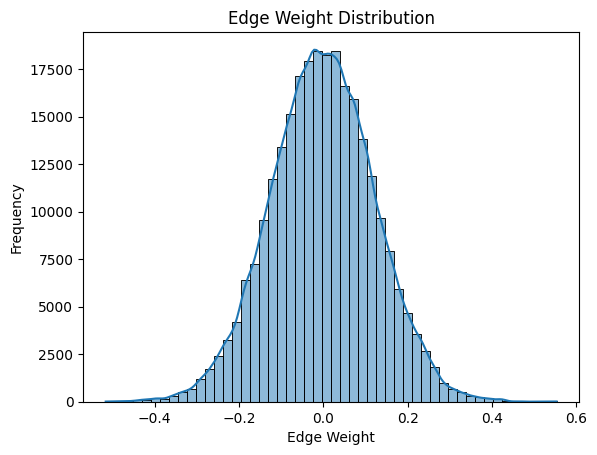

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect all edge weights
all_edge_weights = []

for graph in graphs:
    for u, v, data in graph.edges(data=True):
        all_edge_weights.append(data['weight'])

# Plot distribution
sns.histplot(all_edge_weights, bins=50, kde=True)
plt.xlabel("Edge Weight")
plt.ylabel("Frequency")
plt.title("Edge Weight Distribution")
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Convert to numpy array
all_edge_weights = np.array(all_edge_weights).reshape(-1, 1)

# Apply StandardScaler
scaler = StandardScaler()
scaled_weights = scaler.fit_transform(all_edge_weights)

# Assign back to graphs
index = 0
for graph in graphs:
    for u, v, data in graph.edges(data=True):
        data['weight'] = scaled_weights[index][0]
        index += 1

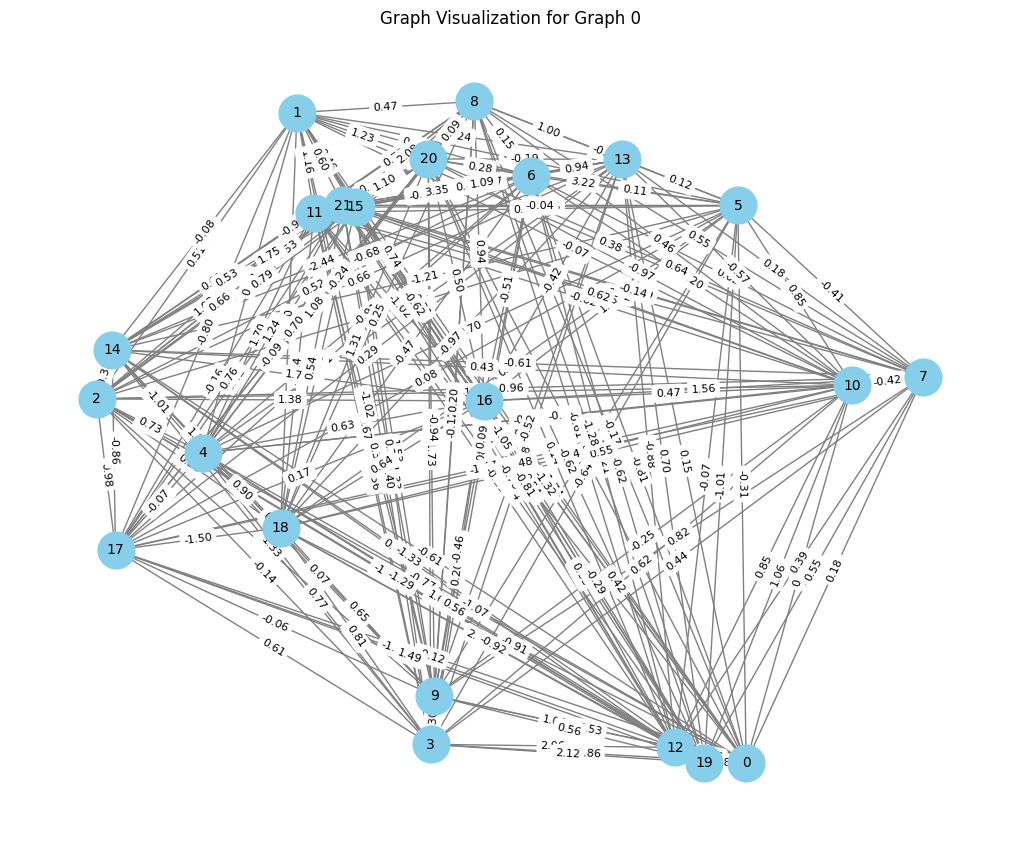

In [22]:
import matplotlib.pyplot as plt

# Select the first graph in the list (or any index you'd like)
graph_index = 0
G = graphs[graph_index]

# Plot the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Layout for better visualization

# Draw the graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=700,
    font_size=10,
    edge_color='gray',
)

# Add edge labels to show weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={k: f"{v:.2f}" for k, v in edge_labels.items()},  # Format weights to 2 decimals
    font_size=8,
)

plt.title(f"Graph Visualization for Graph {graph_index}")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

# Split the graphs and labels
train_graphs, test_graphs, train_labels, test_labels = train_test_split(
    graphs, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train set: {len(train_graphs)} graphs")
print(f"Test set: {len(test_graphs)} graphs")

Train set: 921 graphs
Test set: 231 graphs


In [24]:
def graph_to_data(graph, label):
    # Get edge indices
    edge_index = torch.tensor(list(graph.edges), dtype=torch.long).t().contiguous()
    
    # Get edge weights (connectivity values)
    edge_weights = torch.tensor([graph.edges[e]['weight'] for e in graph.edges()], dtype=torch.float)
    
    # Get node features
    node_features = torch.tensor([graph.nodes[node]['features'] for node in graph.nodes], dtype=torch.float)

    # Create data object with edge attributes
    data = Data(
        x=node_features, 
        edge_index=edge_index, 
        edge_attr=edge_weights,  # Add this line
        y=torch.tensor(label, dtype=torch.long)
    )
    return data

# Create list of Data objects
data_list_train = [graph_to_data(graph, train_labels[i]) for i, graph in enumerate(train_graphs)]
data_list_test = [graph_to_data(graph, test_labels[i]) for i, graph in enumerate(test_graphs)]


train_loader = DataLoader(data_list_train, batch_size=1, shuffle=True)
test_loader = DataLoader(data_list_test, batch_size=1, shuffle=False)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_1576/3513779558.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  node_features = torch.tensor([graph.nodes[node]['features'] for node in graph.nodes], dtype=torch.float)


In [25]:
len(train_loader)

921

In [26]:
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, GCNConv):
        torch.nn.init.xavier_uniform_(m.weight)

In [29]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from torch_geometric.nn import TopKPooling



class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        # GCN branch
        self.gcn1 = GCNConv(num_node_features, hidden_channels)
        self.dropout_sage = nn.Dropout(p=0.5)
        self.gcn2 = GCNConv(hidden_channels, 32)  # Adjust input size
        # self.gcn3 = SAGEConv(100 + hidden_channels + num_node_features, 32)  # Adjust input size
        # GAT branch
        self.gat1 = GATConv(num_node_features, hidden_channels)
        self.dropout_gat = nn.Dropout(p=0.5)
        self.gat2 = GATConv(hidden_channels, 32)  # Adjust input size
        # self.gat3 = GATConv(100 + hidden_channels + num_node_features, 32)  # Adjust input size
        # Chebyshev branch
        self.cheb1 = ChebConv(num_node_features, hidden_channels, K=2)
        self.dropout_cheb = nn.Dropout(p=0.5)
        self.cheb2 = ChebConv(hidden_channels, 32, K=2)  # Adjust input size
        # self.cheb3 = ChebConv(100 + hidden_channels + num_node_features, 32, K=2)  # Adjust input size
        # GraphSAGE branch
        self.sage1 = SAGEConv(num_node_features, hidden_channels)
        self.dropout_sage = nn.Dropout(p=0.5)
        self.sage2 = SAGEConv(hidden_channels, 32)  # Adjust input size
        # self.sage3 = SAGEConv(100 + hidden_channels + num_node_features, 32)  # Adjust input size
        # Batch normalization
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(100)
        # Fully connected layer for classification
        self.fc = torch.nn.Linear(32*4, num_classes)  # Updated input size to 128

    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # GCN branch
        x_gcn = self.dropout_sage(F.leaky_relu(self.gcn1(x, edge_index)))
        x_gcn = self.dropout_sage(F.leaky_relu(self.gcn2(x_gcn, edge_index)))
        x_gcn = global_mean_pool(x_gcn, batch)  # Global Average Pooling

        # GAT branch
        x_gat = self.dropout_gat(F.leaky_relu(self.gat1(x, edge_index)))
        x_gat = self.dropout_gat(F.leaky_relu(self.gat2(x_gat, edge_index)))
        x_gat = global_mean_pool(x_gat, batch)

        # Chebyshev branch
        x_cheb = self.dropout_cheb(F.leaky_relu(self.cheb1(x, edge_index)))
        x_cheb = self.dropout_cheb(F.leaky_relu(self.cheb2(x_cheb, edge_index)))
        x_cheb = global_mean_pool(x_cheb, batch)

        # GraphSAGE branch
        x_sage = self.dropout_sage(F.leaky_relu(self.sage1(x, edge_index)))
        x_sage = self.dropout_sage(F.leaky_relu(self.sage2(x_sage, edge_index)))
        x_sage = global_mean_pool(x_sage, batch)

        # Concatenate outputs from all branches
        x = torch.cat((x_gcn, x_gat, x_cheb, x_sage), dim=1)

        # Fully connected layer for classification
        x = self.fc(x)

        return x

in_channels = 5
hidden_channels = 100
out_channels = 2
model = GCN(in_channels, hidden_channels, out_channels)
# model.apply(init_weights)
print(model)

GCN(
  (gcn1): GCNConv(5, 100)
  (dropout_sage): Dropout(p=0.5, inplace=False)
  (gcn2): GCNConv(100, 32)
  (gat1): GATConv(5, 100, heads=1)
  (dropout_gat): Dropout(p=0.5, inplace=False)
  (gat2): GATConv(100, 32, heads=1)
  (cheb1): ChebConv(5, 100, K=2, normalization=sym)
  (dropout_cheb): Dropout(p=0.5, inplace=False)
  (cheb2): ChebConv(100, 32, K=2, normalization=sym)
  (sage1): SAGEConv(5, 100, aggr=mean)
  (sage2): SAGEConv(100, 32, aggr=mean)
  (bn1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [31]:
class GCN(nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels//2)
        self.conv4 = GCNConv(hidden_channels//2, hidden_channels//2)
        
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels//2)
        self.bn4 = nn.BatchNorm1d(hidden_channels//2)
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_channels//2, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # First conv block
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Second conv block
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Third conv block
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Fourth conv block
        x = self.conv4(x, edge_index)
        x = self.bn4(x)
        x = F.relu(x)
        
        # Global pooling
        x = global_mean_pool(x, batch)
        
        # Classification head
        x = self.fc(x)
        return F.log_softmax(x, dim=1)

in_channels = 5
hidden_channels = 100
out_channels = 2
model = GCN(in_channels, hidden_channels, out_channels)
# model.apply(init_weights)
print(model)

GCN(
  (conv1): GCNConv(5, 100)
  (conv2): GCNConv(100, 100)
  (conv3): GCNConv(100, 50)
  (conv4): GCNConv(50, 50)
  (bn1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=50, out_features=2, bias=True)
)


In [32]:
class GCN(nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels//2)
        
        self.edge_attention = nn.Sequential(
            nn.Linear(1, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1),
            nn.Sigmoid()
        )
        
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels//2)
        
        self.dropout = nn.Dropout(0.3)
        
        self.fc_local = nn.Linear(hidden_channels//2, hidden_channels//4)
        self.fc_global = nn.Linear(hidden_channels//2, hidden_channels//4)
        self.fc_out = nn.Linear(hidden_channels//2, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch
        
        # Handle edge weights
        if hasattr(data, 'edge_attr') and data.edge_attr is not None:
            edge_weights = self.edge_attention(data.edge_attr.unsqueeze(-1)).squeeze()
        else:
            edge_weights = None
        
        # First conv block
        x = self.conv1(x, edge_index, edge_weight=edge_weights)
        x = self.bn1(x)
        x = F.elu(x)
        x = self.dropout(x)
        
        # Second conv block
        x = self.conv2(x, edge_index, edge_weight=edge_weights)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.dropout(x)
        
        # Third conv block
        x = self.conv3(x, edge_index, edge_weight=edge_weights)
        x = self.bn3(x)
        x = F.elu(x)
        
        # Parallel pooling
        x_local = global_add_pool(x, batch)
        x_global = global_mean_pool(x, batch)
        
        x_local = self.fc_local(x_local)
        x_global = self.fc_global(x_global)
        
        x = torch.cat([x_local, x_global], dim=1)
        x = self.fc_out(x)
        return F.log_softmax(x, dim=1)

in_channels = 5
hidden_channels = 100
out_channels = 2
model = GCN(in_channels, hidden_channels, out_channels)
print(model)

GCN(
  (conv1): GCNConv(5, 100)
  (conv2): GCNConv(100, 100)
  (conv3): GCNConv(100, 50)
  (edge_attention): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (bn1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_local): Linear(in_features=50, out_features=25, bias=True)
  (fc_global): Linear(in_features=50, out_features=25, bias=True)
  (fc_out): Linear(in_features=50, out_features=2, bias=True)
)


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # Move model to GPU
for m in model.modules():
    if isinstance(m, torch.nn.Conv2d):
        torch.nn.init.xavier_uniform_(m.weigh, nonlinearity='relu')

train_accuracies = []
test_accuracies = []
train_loss = []

# Define optimizer, loss, and scheduler
# Improved optimizer configuration
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-5)

# Add gradient clipping
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

def train():
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        # Fix this line - use criterion instead of optimizer for loss
        loss = F.nll_loss(out, data.y.view(-1))  # or use CrossEntropyLoss if you prefer
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
        total += data.y.size(0)
        total_loss += loss.item()
        
    print(f"Train Loss: {total_loss / len(train_loader):.4f}")
    return total_loss / len(train_loader), correct / total


# Evaluation function
# @torch.no_grad()
def test(loader):
    model.eval()
    correct = 0
    total = 0
    for data in loader:
        data = data.to(device)  # Move data to GPU
        out = model(data)
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
        total += data.y.size(0)
    
    return correct / total  # Accuracy

# Training Loop
num_epochs = 100
for epoch in range(num_epochs):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # scheduler.step(test_acc)  # Update learning rate based on test accuracy
    
    print(f"Epoch {epoch+1:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")


Train Loss: 1.1199
Epoch 001, Train Acc: 0.5114, Test Acc: 0.4762, LR: 0.001000
Train Loss: 1.1074
Epoch 002, Train Acc: 0.5005, Test Acc: 0.4978, LR: 0.001000
Train Loss: 0.7552
Epoch 003, Train Acc: 0.5071, Test Acc: 0.4719, LR: 0.001000
Train Loss: 1.0069
Epoch 004, Train Acc: 0.5071, Test Acc: 0.4978, LR: 0.001000
Train Loss: 0.7635
Epoch 005, Train Acc: 0.5125, Test Acc: 0.4632, LR: 0.001000
Train Loss: 0.7618
Epoch 006, Train Acc: 0.5005, Test Acc: 0.5022, LR: 0.001000
Train Loss: 0.7774
Epoch 007, Train Acc: 0.4962, Test Acc: 0.4978, LR: 0.001000


KeyboardInterrupt: 

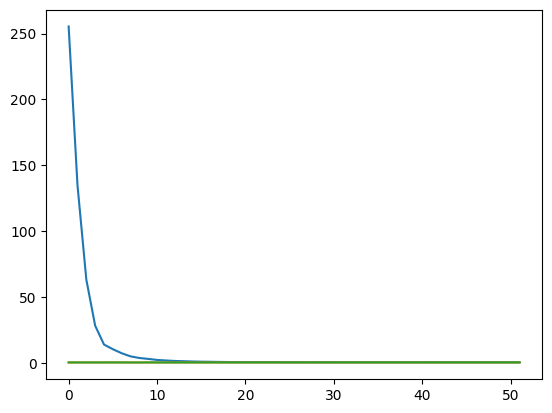

In [217]:
import matplotlib.pyplot as plt
plt.plot(train_loss, label='Train Loss')
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')

In [232]:
import torch.optim as optim
train_accuracies = []
test_accuracies = []

# num_epochs = 50
# Define optimizer and loss
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)
criterion = nn.CrossEntropyLoss()

# Train the model
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()  # Clear gradients
        out = model(data)  # Forward pass
        # print(out)
        loss = criterion(out, data.y)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        total_loss += loss.item()
    print(f"Train Loss: {total_loss / len(train_loader):.4f}")

# Test the model
def test(loader):
    model.eval()
    correct = 0
    for data in loader:
        out = model(data)
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset)

# Main training loop
num_epochs = 100
for epoch in range(num_epochs):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


AttributeError: 'NoneType' object has no attribute 'unsqueeze'

In [77]:
import numpy as np
unique, counts = np.unique(train_labels, return_counts=True)
print(dict(zip(unique, counts)))

{0: 460, 1: 461}


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Each trial becomes a vector of 22 channels * 5 features = 110 dimensions
features_flat = features[:,0,:]  # Shape: (1152, 110)

# Standardize the features (recommended for PCA)
# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(features_flat)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_flat)  # Shape: (1152, 2)

# Explained variance ratio (how much information is retained)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

# Plot PCA results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of EEG Features (1152 Trials, 2 Classes)')
plt.grid(True)
plt.show()

# Optional: 3D PCA plot
pca_3d = PCA(n_components=2)
features_pca_3d = pca_3d.fit_transform(features_scaled)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(features_pca_3d[:, 0], features_pca_3d[:, 1], features_pca_3d[:, 2], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Class')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA of EEG Features')
plt.show()
print("3D Explained variance ratio:", pca_3d.explained_variance_ratio_)
print("Total variance explained (3D):", sum(pca_3d.explained_variance_ratio_))

Explained variance ratio: [1.]
Total variance explained: 1.0


IndexError: index 1 is out of bounds for axis 1 with size 1

<Figure size 800x600 with 0 Axes>

In [50]:
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative variance: {np.sum(pca.explained_variance_ratio_)}")

Explained variance ratio: [0.24492535 0.21697901]
Cumulative variance: 0.46190435341600267


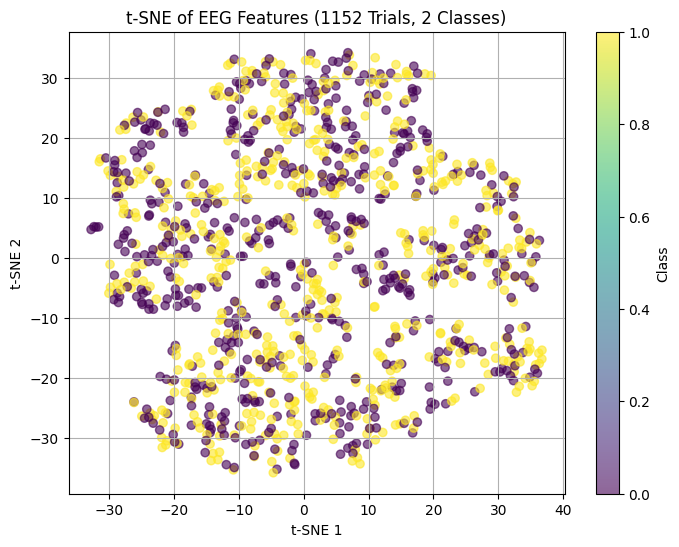

In [51]:
from sklearn.manifold import TSNE

# t-SNE on standardized features
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_tsne = tsne.fit_transform(features_scaled)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Class')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of EEG Features (1152 Trials, 2 Classes)')
plt.grid(True)
plt.show()

/Users/siddharth/Documents/Brainconnectivity/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/siddharth/Documents/Brainconnectivity/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


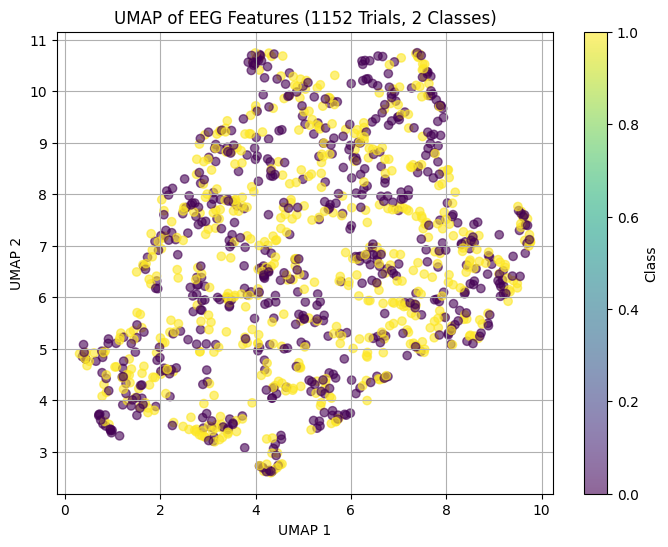

In [52]:
import umap

# UMAP on standardized features
umap_model = umap.UMAP(n_components=2, n_neighbors=15, random_state=42)
features_umap = umap_model.fit_transform(features_scaled)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_umap[:, 0], features_umap[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Class')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP of EEG Features (1152 Trials, 2 Classes)')
plt.grid(True)
plt.show()

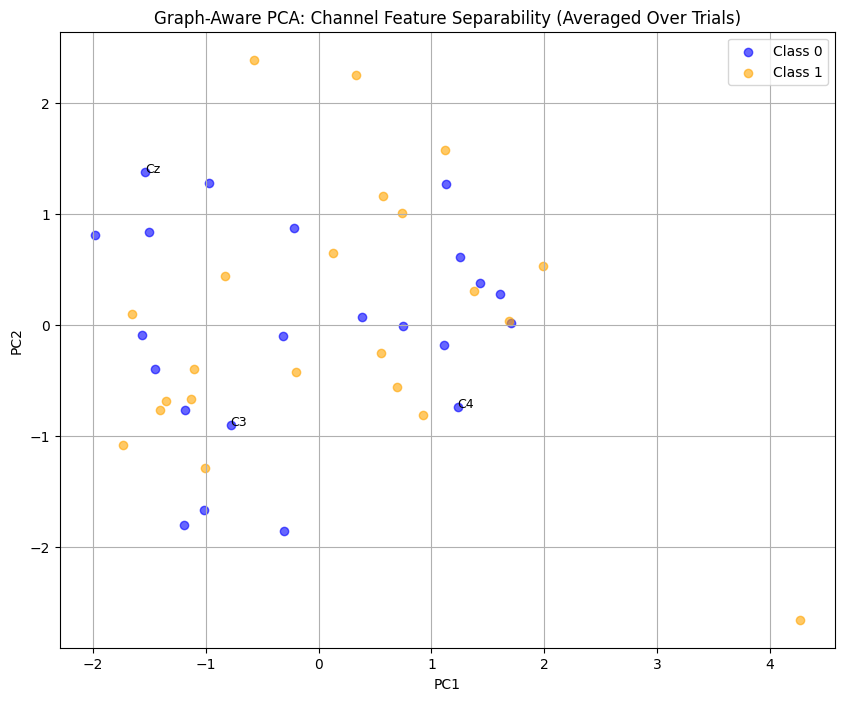

Explained variance ratio: [0.35186302 0.22247708]
Total variance explained: 0.5743400972200227


In [53]:
channel_names = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 
                 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']

# Step 1: Compute mean features per channel for each class
n_channels = 22
n_features = 5
n_classes = 2
mean_features_per_class = np.zeros((n_classes, n_channels, n_features))  # Shape: (4, 22, 5)

for class_idx in range(n_classes):
    # Select trials for this class
    class_trials = features[labels == class_idx]  # Shape: (n_trials_for_class, 22, 5)
    # Average over trials for each channel
    mean_features_per_class[class_idx] = np.mean(class_trials, axis=0)  # Shape: (22, 5)

# Step 2: Flatten and standardize for PCA
# Combine all class data: (4 classes * 22 channels, 5 features) = (88, 5)
features_flat = mean_features_per_class.reshape(-1, n_features)  # Shape: (88, 5)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flat)

# Step 3: Apply PCA to reduce to 2D
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)  # Shape: (88, 2)

# Step 4: Prepare labels for plotting (repeat channel names for each class)
class_labels = np.repeat(np.arange(n_classes), n_channels)  # Shape: (88,) - [0,0,...,1,1,...,2,2,...,3,3,...]
channel_labels = np.tile(np.arange(n_channels), n_classes)  # Shape: (88,) - [0,1,...,21,0,1,...,21,...]

# Step 5: Plot
plt.figure(figsize=(10, 8))
colors = ['blue', 'orange', 'green', 'red']  # One color per class
for class_idx in range(n_classes):
    idx = class_labels == class_idx
    plt.scatter(features_pca[idx, 0], features_pca[idx, 1], c=colors[class_idx], 
                label=f'Class {class_idx}', alpha=0.6)

# Optionally annotate a few key channels (e.g., C3, C4, Cz) for one class
for i, (x, y) in enumerate(features_pca[:n_channels]):  # First class only for clarity
    if channel_names[i] in ['C3', 'C4', 'Cz']:  # Highlight motor cortex channels
        plt.text(x, y, channel_names[i], fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Graph-Aware PCA: Channel Feature Separability (Averaged Over Trials)')
plt.legend()
plt.grid(True)
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

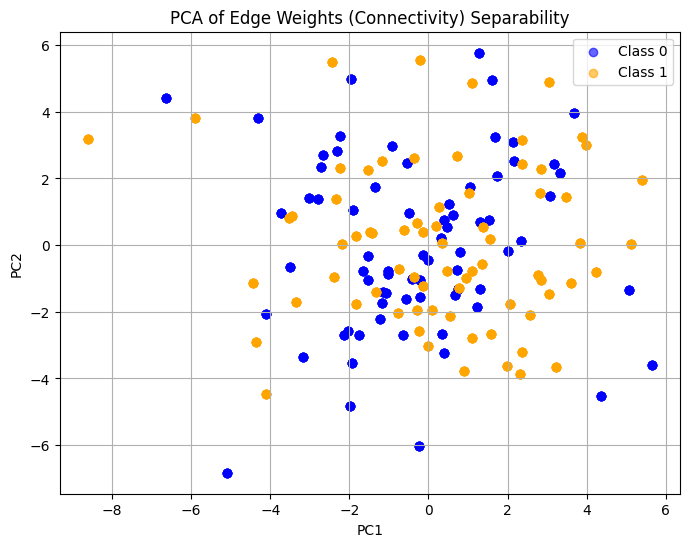

2D Explained variance ratio: [0.02579163 0.0253869 ]
2D Total variance explained: 0.051178532527070136


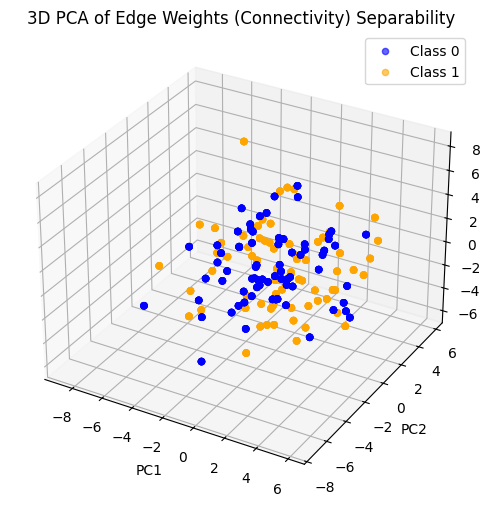

3D Explained variance ratio: [0.02569555 0.02534024 0.02467291]
3D Total variance explained: 0.07570870265036395


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Assuming connectivity_0_trials and connectivity_1_trials are loaded
# connectivity_0_trials.shape = (576, 22, 22)
# connectivity_1_trials.shape = (576, 22, 22)

def vectorize_connectivity(conn_matrix):
    return conn_matrix[np.tril_indices(22, k=-1)]  # Lower triangle, k=-1 skips diagonal

# Vectorize connectivity matrices
conn_0_vectors = np.array([vectorize_connectivity(conn) for conn in connectivity_0_trials])  # (576, 231)
conn_1_vectors = np.array([vectorize_connectivity(conn) for conn in connectivity_1_trials])  # (576, 231)

# Standardize the vectors
scaler = StandardScaler()
conn_0_scaled = scaler.fit_transform(conn_0_vectors)
conn_1_scaled = scaler.transform(conn_1_vectors)  # Use same scaler for consistency

# Combine classes for PCA
all_conn = np.vstack([conn_0_scaled, conn_1_scaled])  # (1152, 231)
labels = np.hstack([np.zeros(576), np.ones(576)])  # 0 for Class 0, 1 for Class 1

# 2D PCA
pca_2d = PCA(n_components=2)
conn_pca_2d = pca_2d.fit_transform(all_conn)  # (1152, 2)

# Plot 2D PCA
plt.figure(figsize=(8, 6))
plt.scatter(conn_pca_2d[:576, 0], conn_pca_2d[:576, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(conn_pca_2d[576:, 0], conn_pca_2d[576:, 1], c='orange', label='Class 1', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Edge Weights (Connectivity) Separability')
plt.legend()
plt.grid(True)
plt.show()

# Print explained variance for 2D
print("2D Explained variance ratio:", pca_2d.explained_variance_ratio_)
print("2D Total variance explained:", sum(pca_2d.explained_variance_ratio_))

# 3D PCA
pca_3d = PCA(n_components=3)
conn_pca_3d = pca_3d.fit_transform(all_conn)  # (1152, 3)

# Plot 3D PCA
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(conn_pca_3d[:576, 0], conn_pca_3d[:576, 1], conn_pca_3d[:576, 2], 
                    c='blue', label='Class 0', alpha=0.6)
scatter = ax.scatter(conn_pca_3d[576:, 0], conn_pca_3d[576:, 1], conn_pca_3d[576:, 2], 
                    c='orange', label='Class 1', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA of Edge Weights (Connectivity) Separability')
ax.legend()
plt.show()

# Print explained variance for 3D
print("3D Explained variance ratio:", pca_3d.explained_variance_ratio_)
print("3D Total variance explained:", sum(pca_3d.explained_variance_ratio_))

In [64]:
conn_0_vectors.shape

(576, 231)

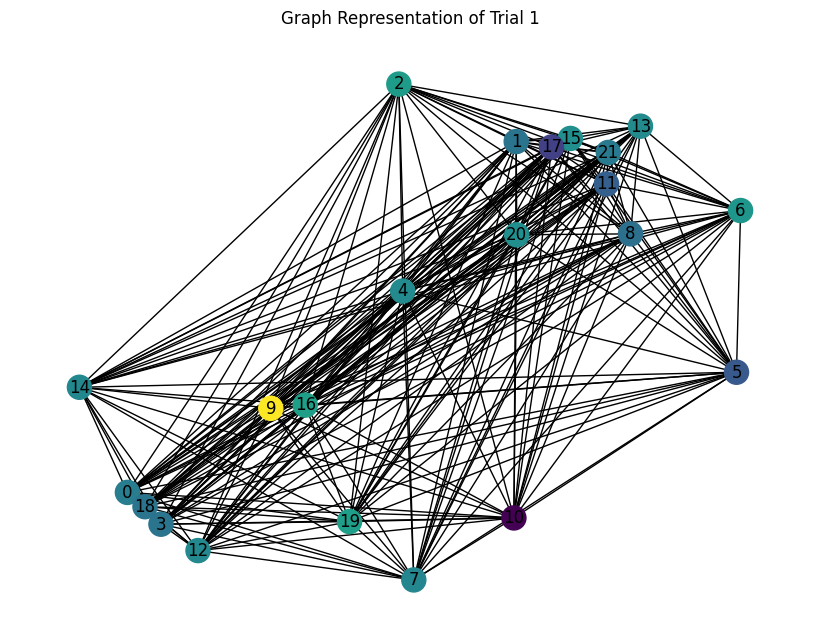

In [146]:
import networkx as nx
import matplotlib.pyplot as plt

# Function to visualize a sample graph
def visualize_graph(graph, title="Graph Visualization"):
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph)  # Compute node positions
    node_colors = [graph.nodes[node]['features'][0] for node in graph.nodes]  # Using first feature for color
    
    nx.draw(graph, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.viridis, node_size=300)
    plt.title(title)
    plt.show()

# Visualize the first few graphs
visualize_graph(graphs[0], title="Graph Representation of Trial 1")


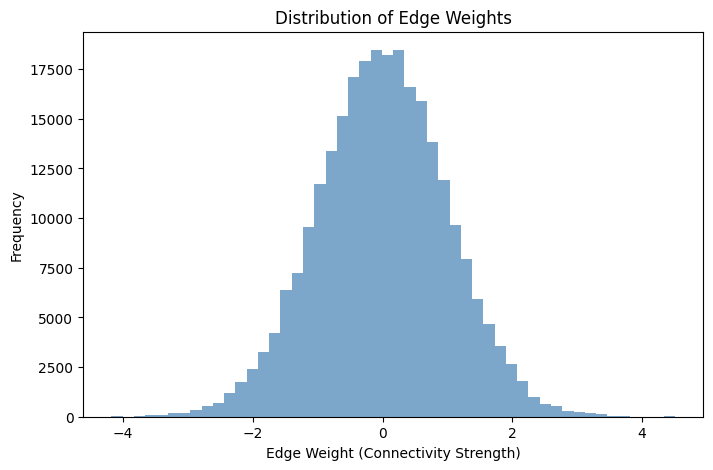

In [147]:
import numpy as np

# Extract edge weights
edge_weights = []
for graph in graphs:
    for _, _, data in graph.edges(data=True):
        edge_weights.append(data['weight'])

# Plot histogram of edge weights
plt.figure(figsize=(8, 5))
plt.hist(edge_weights, bins=50, color='steelblue', alpha=0.7)
plt.title("Distribution of Edge Weights")
plt.xlabel("Edge Weight (Connectivity Strength)")
plt.ylabel("Frequency")
plt.show()

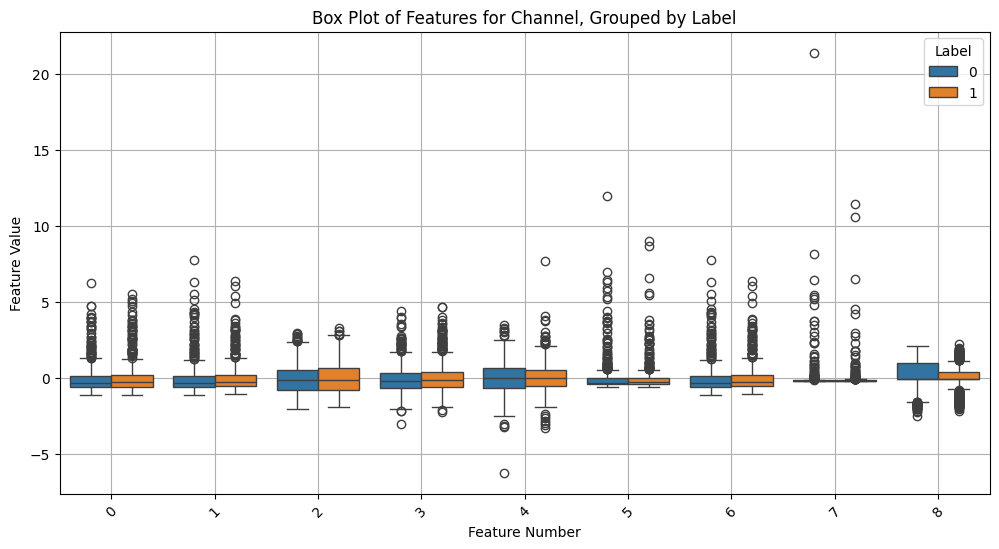

In [81]:
import pandas as pd
import seaborn as sns

channel_feature = features[:,10,:]
scaler = StandardScaler()
channel_feature_scaled = scaler.fit_transform(channel_feature)
df = pd.DataFrame(channel_feature_scaled)
df['Label'] = labels  # Add labels column
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.melt(id_vars=['Label'], var_name='Feature', value_name='Value'), x='Feature', y='Value', hue='Label')

# Customize plot
plt.title("Box Plot of Features for Channel, Grouped by Label")
plt.xlabel("Feature Number")
plt.ylabel("Feature Value")
plt.legend(title="Label")
plt.xticks(rotation=45)
plt.grid()

# Show plot
plt.show()

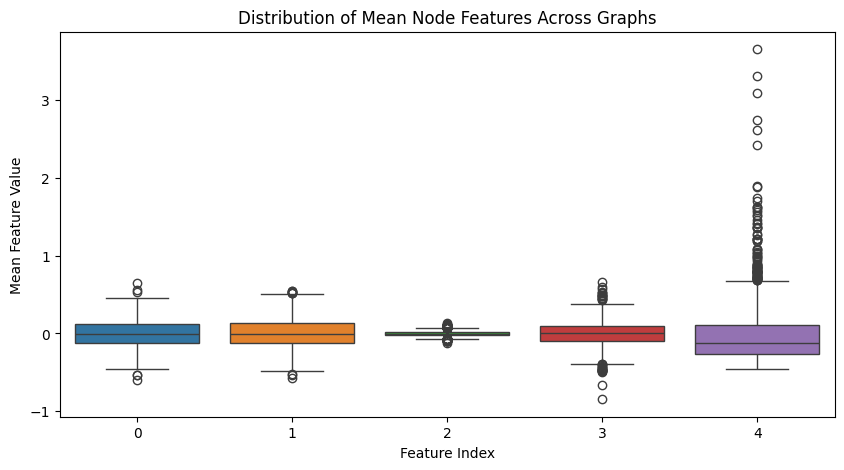

In [61]:
import pandas as pd

# Compute mean feature per graph
graph_features = []
for graph in graphs:
    node_feats = np.array([graph.nodes[node]['features'] for node in graph.nodes])
    graph_features.append(np.mean(node_feats, axis=0))  # Compute mean feature per graph

graph_features = np.array(graph_features)

# Plot feature distributions
plt.figure(figsize=(10, 5))
sns.boxplot(data=pd.DataFrame(graph_features))
plt.title("Distribution of Mean Node Features Across Graphs")
plt.xlabel("Feature Index")
plt.ylabel("Mean Feature Value")
plt.show()

EEG Data Shape: (144, 22, 751), Labels Shape: (144,)


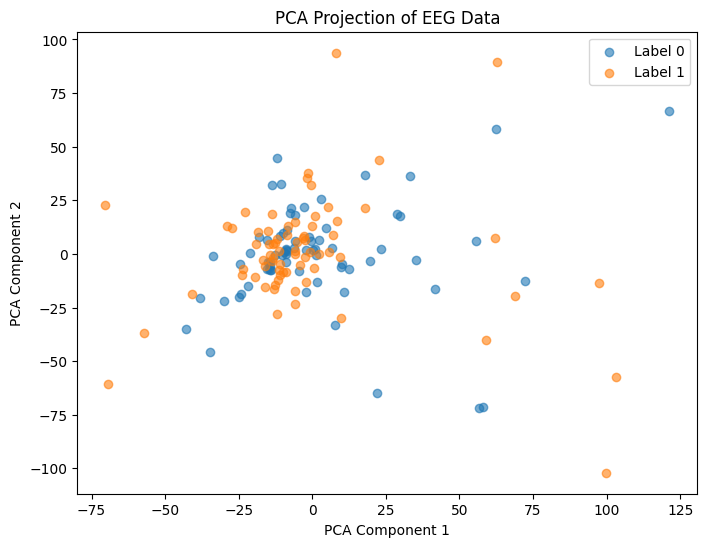

              precision    recall  f1-score   support

           0       0.75      0.20      0.32        15
           1       0.52      0.93      0.67        14

    accuracy                           0.55        29
   macro avg       0.64      0.56      0.49        29
weighted avg       0.64      0.55      0.49        29



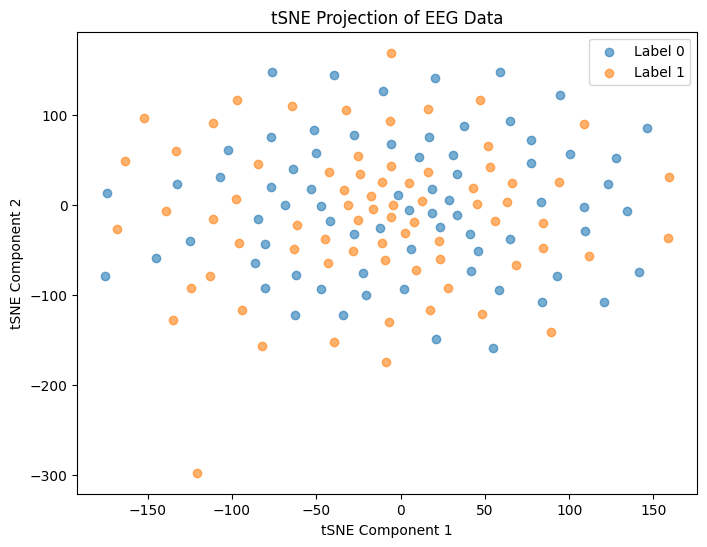

              precision    recall  f1-score   support

           0       0.40      0.40      0.40        15
           1       0.36      0.36      0.36        14

    accuracy                           0.38        29
   macro avg       0.38      0.38      0.38        29
weighted avg       0.38      0.38      0.38        29



In [129]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Load EEG data and labels from a specific subject
def load_data_for_subject(directory_path):
    mat = scipy.io.loadmat(directory_path)
    eeg_data = mat['eeg_data']  # Shape: (trials, channels, datapoints)
    labels = mat['labels'].flatten()  # Shape: (trials,)
    
    # Assuming subject_id is part of the filename, for example, "subject_1.mat"
    return eeg_data, labels

# Analyze separability
def analyze_separability(eeg_data, labels, method="PCA"):
    # Flatten EEG data to (trials, features) for dimensionality reduction
    trials, channels, datapoints = eeg_data.shape
    eeg_data_flattened = eeg_data.reshape(trials, channels * datapoints)
    
    # Scale the data
    scaler = StandardScaler()
    eeg_data_scaled = scaler.fit_transform(eeg_data_flattened)

    # Dimensionality reduction
    if method == "PCA":
        reducer = PCA(n_components=2, random_state=42)
    elif method == "tSNE":
        reducer = TSNE(n_components=2, random_state=42)
    else:
        raise ValueError("Method must be 'PCA' or 'tSNE'")
    
    reduced_data = reducer.fit_transform(eeg_data_scaled)

    # Visualization
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        plt.scatter(reduced_data[labels == label, 0], reduced_data[labels == label, 1], label=f"Label {label}", alpha=0.6)
    plt.title(f"{method} Projection of EEG Data")
    plt.xlabel(f"{method} Component 1")
    plt.ylabel(f"{method} Component 2")
    plt.legend()
    plt.show()

    # Classification for separability assessment
    X_train, X_test, y_train, y_test = train_test_split(reduced_data, labels, test_size=0.2, random_state=42, stratify=labels)
    clf = SVC(kernel='linear', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(classification_report(y_test, y_pred))

# Main function
if __name__ == "__main__":
    directory_path = "/Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub3.mat"  # Replace with your directory path
    eeg_data, labels = load_data_for_subject(directory_path)
    print(f"EEG Data Shape: {eeg_data.shape}, Labels Shape: {labels.shape}")

    # PCA-based analysis
    analyze_separability(eeg_data, labels, method="PCA")

    # t-SNE-based analysis
    analyze_separability(eeg_data, labels, method="tSNE")


EEG Data Shape: (144, 22, 751), Labels Shape: (144,)


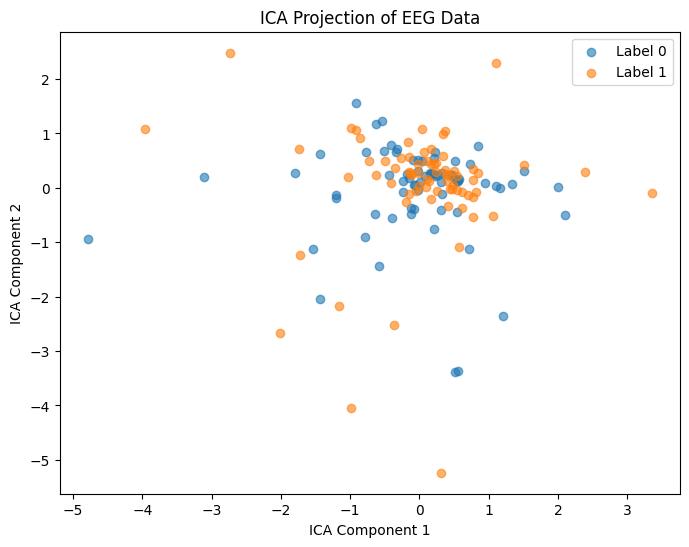

              precision    recall  f1-score   support

           0       0.75      0.20      0.32        15
           1       0.52      0.93      0.67        14

    accuracy                           0.55        29
   macro avg       0.64      0.56      0.49        29
weighted avg       0.64      0.55      0.49        29



In [128]:
# Load EEG data and labels for a specific subject
from sklearn.decomposition import PCA, FastICA
def load_data_for_subject(directory_path):
    mat = scipy.io.loadmat(directory_path)
    eeg_data = mat['eeg_data']  # Shape: (trials, channels, datapoints)
    labels = mat['labels'].flatten()  # Shape: (trials,)
    
    # Assuming subject_id is part of the filename, for example, "subject_1.mat"
    return eeg_data, labels


# Apply ICA for separability analysis
def analyze_separability_with_ica(eeg_data, labels):
    # Flatten EEG data to (trials, features) for dimensionality reduction
    trials, channels, datapoints = eeg_data.shape
    eeg_data_flattened = eeg_data.reshape(trials, channels * datapoints)
    
    # Scale the data
    scaler = StandardScaler()
    eeg_data_scaled = scaler.fit_transform(eeg_data_flattened)

    # Apply ICA
    ica = FastICA(n_components=2, random_state=42)
    ica_components = ica.fit_transform(eeg_data_scaled)

    # Visualization of ICA components
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        plt.scatter(ica_components[labels == label, 0], ica_components[labels == label, 1], label=f"Label {label}", alpha=0.6)
    plt.title("ICA Projection of EEG Data")
    plt.xlabel("ICA Component 1")
    plt.ylabel("ICA Component 2")
    plt.legend()
    plt.show()

    # Classification for separability assessment using ICA components
    X_train, X_test, y_train, y_test = train_test_split(ica_components, labels, test_size=0.2, random_state=42, stratify=labels)
    clf = SVC(kernel='linear', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(classification_report(y_test, y_pred))

# Main function
if __name__ == "__main__":
    directory_path = "/Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub3.mat"  # Replace with your directory path
    subject_id = 2 # Replace with the subject ID you want to analyze
    eeg_data, labels = load_data_for_subject(directory_path)
    
    if eeg_data is None or labels is None:
        print("Error: No data found for the specified subject.")
    else:
        print(f"EEG Data Shape: {eeg_data.shape}, Labels Shape: {labels.shape}")
        # ICA-based analysis
        analyze_separability_with_ica(eeg_data, labels)


In [132]:
features.shape

(1152, 22, 17)

In [133]:
reshaped_features = features.mean(axis = 1)

In [13]:
reshaped_features = features.reshape(1152*22,17)

In [135]:
labels.shape

(1152,)

In [136]:
import scipy.io
scipy.io.savemat('/Users/siddharth/Documents/Brainconnectivity/labels_reshaped.mat', {'GROUP': labels})
scipy.io.savemat('/Users/siddharth/Documents/Brainconnectivity/features_reshaped.mat', {'features': reshaped_features})

In [176]:
from torch_geometric.nn import GraphConv, ChebConv, global_mean_pool

In [14]:
class GraphConvBlock(nn.Module):
    """Block with two GraphConv layers in series and global mean pooling."""
    def __init__(self, in_channels, hidden_channels):
        super(GraphConvBlock, self).__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Norm after first layer
        self.conv2 = GraphConv(hidden_channels, hidden_channels//2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = global_mean_pool(x, batch)  # Graph-level feature
        return x

class ChebConvBlock(nn.Module):
    """Block with two ChebConv layers in series and global mean pooling."""
    def __init__(self, in_channels, hidden_channels, K=2):
        super(ChebConvBlock, self).__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Norm after first layer
        self.conv2 = ChebConv(hidden_channels, hidden_channels//2, K)  # Integer division

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = global_mean_pool(x, batch)  # Graph-level feature
        return x

class SAGEConvBlock(nn.Module):
    """Block with two SAGEConv layers in series and global mean pooling."""
    def __init__(self, in_channels, hidden_channels):
        super(SAGEConvBlock, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Norm after first layer
        self.conv2 = SAGEConv(hidden_channels, hidden_channels//2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = global_mean_pool(x, batch)  # Graph-level feature
        return x

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=20):
        super(GCN, self).__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels*3, out_channels)  # Updated input size

    def forward(self, x, edge_index, edge_weight, batch):
        graph_features = self.graph_block(x, edge_index, edge_weight, batch)
        cheb_features = self.cheb_block(x, edge_index, edge_weight, batch)
        sage_features = self.sage_block(x, edge_index, edge_weight, batch)
        x = torch.cat([graph_features, cheb_features, sage_features], dim=1)  # Concatenation
        x = self.fc(x)  # Classification layer
        return x

In [15]:
gcn_model = GCN(in_channels=5, hidden_channels=10, out_channels=2, K=2)

NameError: name 'GraphConv' is not defined

In [204]:
print(gcn_model)

GCN(
  (graph_block): GraphConvBlock(
    (conv1): GraphConv(5, 10)
    (bn1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): GraphConv(10, 5)
  )
  (cheb_block): ChebConvBlock(
    (conv1): ChebConv(5, 10, K=2, normalization=sym)
    (bn1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): ChebConv(10, 5, K=2, normalization=sym)
  )
  (sage_block): SAGEConvBlock(
    (conv1): SAGEConv(5, 10, aggr=mean)
    (bn1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): SAGEConv(10, 5, aggr=mean)
  )
  (fc): Linear(in_features=30, out_features=2, bias=True)
)


In [205]:
import torch.optim as optim
train_accuracies = []
test_accuracies = []

# num_epochs = 50
# Define optimizer and loss
optimizer = torch.optim.AdamW(
    gcn_model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)
criterion = nn.CrossEntropyLoss()

# Train the gcn_model
def train():
    gcn_model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()  # Clear gradients
        out = gcn_model(data.x, data.edge_index, data.edge_weight, data.batch)  # Forward pass
        # print(out)
        loss = criterion(out, data.y)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        total_loss += loss.item()
    print(f"Train Loss: {total_loss / len(train_loader):.4f}")

# Test the gcn_model
def test(loader):
    gcn_model.eval()
    correct = 0
    for data in loader:
        out = gcn_model(data.x, data.edge_index, data.edge_weight, data.batch)
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset)

# Main training loop
num_epochs = 100
for epoch in range(num_epochs):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


Train Loss: 0.7038
Epoch 001, Train Acc: 0.4995, Test Acc: 0.5022
Train Loss: 0.7003
Epoch 002, Train Acc: 0.5005, Test Acc: 0.5022
Train Loss: 0.6957
Epoch 003, Train Acc: 0.5005, Test Acc: 0.4978


KeyboardInterrupt: 